In [3]:
!wget https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz

--2026-06-23 10:09:31--  https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
Resolving ai.stanford.edu (ai.stanford.edu)... 171.64.68.10
Connecting to ai.stanford.edu (ai.stanford.edu)|171.64.68.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84125825 (80M) [application/x-gzip]
Saving to: ‘aclImdb_v1.tar.gz’

aclImdb_v1.tar.gz   100%[===================>]  80.23M  9.23MB/s    in 17s     

2026-06-23 10:09:49 (4.75 MB/s) - ‘aclImdb_v1.tar.gz’ saved [84125825/84125825]



In [4]:
!tar -xzf aclImdb_v1.tar.gz

In [5]:
import os

print(os.path.exists("aclImdb"))
print(os.path.exists("aclImdb/train"))

True
True


In [6]:
from sklearn.datasets import load_files

train_data = load_files(
    "aclImdb/train/",
    categories=["pos", "neg"]
)

text_train, y_train = train_data.data, train_data.target

print(f"Jumlah dokumen di data training: {len(text_train)}")
print(text_train[1][:200])

Jumlah dokumen di data training: 25000
b"Words can't describe how bad this movie is. I can't explain it by writing only. You have too see it for yourself to get at grip of how horrible a movie really can be. Not that I recommend you to do th"


Fungsi load_files memuat dataset teks yang tersusun dalam subfolder (misal: "pos" untuk positif dan "neg" untuk negatif).

**Pembersihan Data (Menghapus Tag HTML)**

In [7]:
# Menghapus tag <br /> yang sering muncul di review IMDb
text_train = [doc.replace(b"<br />", b" ") for doc in text_train]

 Sebelum diproses, teks mentah seringkali mengandung artefak pemformatan seperti tag HTML yang tidak memberikan informasi berarti bagi model.


**Memeriksa Keseimbangan Kelas**

In [8]:
print(f"Sampel per kelas (training): {np.bincount(y_train)}")

Sampel per kelas (training): [12500 12500]


Dataset IMDb dirancang seimbang dengan jumlah review positif dan negatif yang sama (masing-masing 12.500).


**Representasi Bag-of-Words (Toy Dataset)**

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

bards_words = ["The fool doth think he is wise,",
               "but the wise man knows himself to be a fool"]
vect = CountVectorizer()
vect.fit(bards_words)

CountVectorizer()

Langkah pertama Bag-of-Words adalah membangun kosakata (vocabulary) dari semua kata unik yang muncul di seluruh dokumen.


**Memeriksa Kosakata yang Terbentuk**

In [10]:
print(f"Ukuran kosakata: {len(vect.vocabulary_)}")
print(f"Isi kosakata:\n{vect.vocabulary_}")

Ukuran kosakata: 13
Isi kosakata:
{'the': 9, 'fool': 3, 'doth': 2, 'think': 10, 'he': 4, 'is': 6, 'wise': 12, 'but': 1, 'man': 8, 'knows': 7, 'himself': 5, 'to': 11, 'be': 0}


Atribut vocabulary_ menyimpan kamus kata beserta indeks angka yang mewakilinya.

**Transformasi Teks ke Angka**

In [11]:
bag_of_words = vect.transform(bards_words)
print(f"Representasi Bag-of-Words (sparse):\n{bag_of_words}")

Representasi Bag-of-Words (sparse):
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 16 stored elements and shape (2, 13)>
  Coords	Values
  (0, 2)	1
  (0, 3)	1
  (0, 4)	1
  (0, 6)	1
  (0, 9)	1
  (0, 10)	1
  (0, 12)	1
  (1, 0)	1
  (1, 1)	1
  (1, 3)	1
  (1, 5)	1
  (1, 7)	1
  (1, 8)	1
  (1, 9)	1
  (1, 11)	1
  (1, 12)	1


 Metode transform mengubah teks menjadi matriks jarang (sparse matrix). Angka di dalam matriks menunjukkan berapa kali kata tersebut muncul dalam dokumen.

**Visualisasi Matriks Padat (Dense)**

In [12]:
print(f"Representasi dalam bentuk array padat:\n{bag_of_words.toarray()}")

Representasi dalam bentuk array padat:
[[0 0 1 1 1 0 1 0 0 1 1 0 1]
 [1 1 0 1 0 1 0 1 1 1 0 1 1]]


Karena kebanyakan sel bernilai nol (kata tidak muncul), kita biasanya menggunakan format sparse. toarray() digunakan untuk melihat visualisasi lengkapnya (hanya untuk data kecil).

**Bag-of-Words pada Data IMDb**

In [13]:
vect = CountVectorizer().fit(text_train)
X_train = vect.transform(text_train)
print(f"X_train shape: {X_train.shape}")

X_train shape: (25000, 74849)


Untuk data IMDb asli, terbentuk sekitar 74.849 fitur (kata unik). Ini menunjukkan dimensi data teks yang sangat tinggi.

**Mengambil Nama Fitur**

In [14]:
feature_names = vect.get_feature_names_out()
print(f"Jumlah fitur: {len(feature_names)}")
print(f"Sepuluh fitur pertama: {feature_names[:10]}")
print(f"Fitur ke-20000 sampai 20010: {feature_names[20000:20010]}")

Jumlah fitur: 74849
Sepuluh fitur pertama: ['00' '000' '0000000000001' '00001' '00015' '000s' '001' '003830' '006'
 '007']
Fitur ke-20000 sampai 20010: ['draper' 'draperies' 'drapery' 'drapes' 'draskovic' 'drastic'
 'drastically' 'drat' 'dratch' 'dratic']


get_feature_names_out memungkinkan kita melihat kata asli apa yang diwakili oleh setiap kolom dalam matriks.

**Evaluasi Awal dengan Logistic Regression**

In [15]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

scores = cross_val_score(LogisticRegression(max_iter=1000), X_train, y_train, cv=5)
print(f"Rata-rata akurasi CV: {np.mean(scores):.2f}")

Rata-rata akurasi CV: 0.88


Model linear seperti LogisticRegression bekerja sangat baik pada data berdimensi tinggi dan jarang (sparse) seperti teks.


**Tuning Parameter C**

In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.001, 0.01, 0.1, 1, 10]}
grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5)
grid.fit(X_train, y_train)
print(f"Skor CV terbaik: {grid.best_score_:.2f}")

Skor CV terbaik: 0.89


Mencari parameter regulasi C yang optimal untuk meningkatkan performa model pada data teks.

**Membatasi Fitur dengan min_df**

In [18]:
# Hanya gunakan kata yang muncul setidaknya di 5 dokumen
vect = CountVectorizer(min_df=5).fit(text_train)
X_train = vect.transform(text_train)
print(f"X_train dengan min_df=5 shape: {X_train.shape}")

X_train dengan min_df=5 shape: (25000, 27271)


Parameter min_df sangat membantu mengurangi noise dengan membuang kata-kata yang terlalu jarang muncul (seringkali berupa typo atau angka acak).


**Menggunakan Stopwords (Kata Henti)**

In [19]:
vect = CountVectorizer(min_df=5, stop_words="english").fit(text_train)
X_train = vect.transform(text_train)
print(f"Jumlah fitur setelah menghapus stopwords: {X_train.shape[1]}")

Jumlah fitur setelah menghapus stopwords: 26966


Menghapus kata-kata umum seperti "the", "and", atau "is" yang biasanya tidak membantu dalam membedakan sentimen review.


**Rescaling dengan tf-idf**

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline

pipe = make_pipeline(TfidfVectorizer(min_df=5), LogisticRegression(max_iter=1000))
param_grid = {'logisticregression__C': [0.001, 0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(text_train, y_train)
print(f"Skor terbaik TF-IDF: {grid.best_score_:.2f}")

Skor terbaik TF-IDF: 0.89


 tf-idf memberikan bobot tinggi pada kata yang sering muncul dalam satu dokumen tapi jarang muncul di dokumen lain, membantu menemukan kata yang unik dan deskriptif.


**Melihat Pentingnya Kata (IDF)**

In [21]:
vectorizer = grid.best_estimator_.named_steps["tfidfvectorizer"]
# Transformasi data latihan
X_train = vectorizer.transform(text_train)
# Temukan nilai idf maksimum
max_val = X_train.max(axis=0).toarray().ravel()
sorted_by_tfidf = max_val.argsort()

feature_names = np.array(vectorizer.get_feature_names_out())
print(f"Fitur dengan tf-idf terendah:\n{feature_names[sorted_by_tfidf[:20]]}")
print(f"Fitur dengan tf-idf tertinggi:\n{feature_names[sorted_by_tfidf[-20:]]}")

Fitur dengan tf-idf terendah:
['suplexes' 'gauche' 'hypocrites' 'oncoming' 'songwriting' 'galadriel'
 'emerald' 'mclaughlin' 'sylvain' 'oversee' 'cataclysmic' 'pressuring'
 'uphold' 'thieving' 'inconsiderate' 'ware' 'denim' 'reverting' 'booed'
 'spacious']
Fitur dengan tf-idf tertinggi:
['gadget' 'sucks' 'zatoichi' 'demons' 'lennon' 'bye' 'dev' 'weller'
 'sasquatch' 'botched' 'xica' 'darkman' 'woo' 'casper' 'doodlebops'
 'smallville' 'wei' 'scanners' 'steve' 'pokemon']


Kata dengan skor tf-idf tinggi biasanya sangat spesifik (seperti nama karakter), sedangkan yang rendah adalah kata yang muncul di mana-mana.

** Investigasi Koefisien Model**

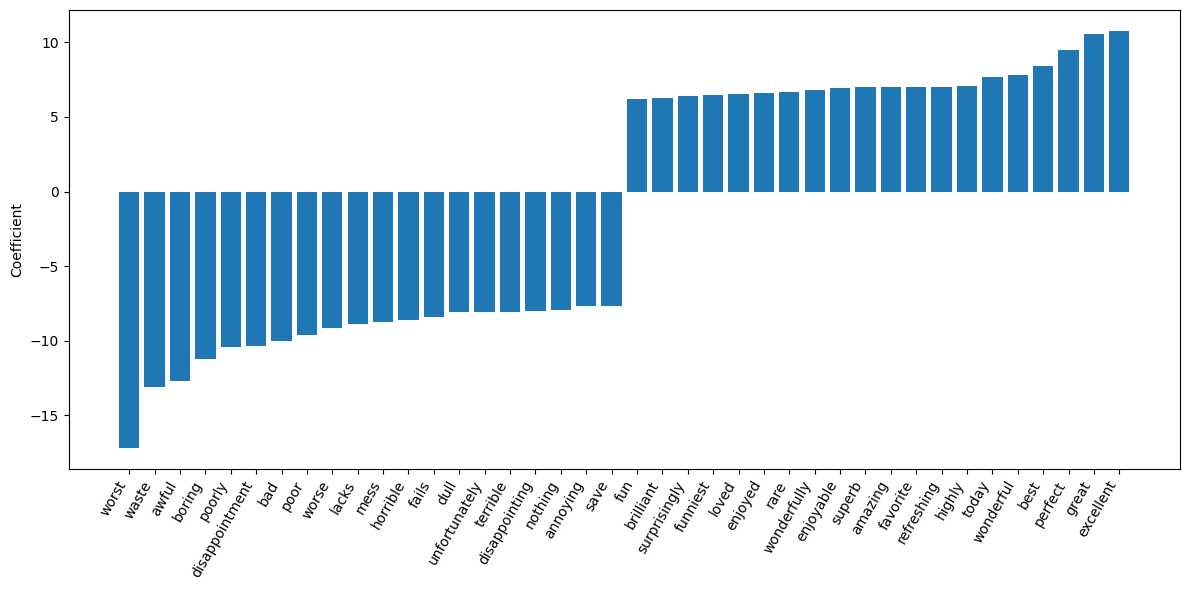

In [23]:
import numpy as np
import matplotlib.pyplot as plt

coef = grid.best_estimator_.named_steps["logisticregression"].coef_.ravel()

top_n = 20
top_positive = np.argsort(coef)[-top_n:]
top_negative = np.argsort(coef)[:top_n]
top_coefficients = np.hstack([top_negative, top_positive])

plt.figure(figsize=(12,6))
plt.bar(
    np.arange(2 * top_n),
    coef[top_coefficients]
)
plt.xticks(
    np.arange(2 * top_n),
    np.array(feature_names)[top_coefficients],
    rotation=60,
    ha="right"
)
plt.ylabel("Coefficient")
plt.tight_layout()
plt.show()

Visualisasi ini menunjukkan kata apa saja yang dianggap model sebagai indikator positif (kanan) dan negatif (kiri).

**Menggunakan n-Grams (Pasangan Kata)**

In [24]:
# Menggunakan unigrams, bigrams, dan trigrams
cv = CountVectorizer(ngram_range=(1, 3)).fit(bards_words)
print(f"Ukuran kosakata n-grams: {len(cv.vocabulary_)}")
print(f"Nama fitur n-grams:\n{cv.get_feature_names_out()}")

Ukuran kosakata n-grams: 39
Nama fitur n-grams:
['be' 'be fool' 'but' 'but the' 'but the wise' 'doth' 'doth think'
 'doth think he' 'fool' 'fool doth' 'fool doth think' 'he' 'he is'
 'he is wise' 'himself' 'himself to' 'himself to be' 'is' 'is wise'
 'knows' 'knows himself' 'knows himself to' 'man' 'man knows'
 'man knows himself' 'the' 'the fool' 'the fool doth' 'the wise'
 'the wise man' 'think' 'think he' 'think he is' 'to' 'to be' 'to be fool'
 'wise' 'wise man' 'wise man knows']


n-grams menangkap konteks kata (misal: "not good" berbeda dengan "good"). ngram_range=(1, 3) mencakup kata tunggal hingga rangkaian tiga kata.

**Tuning n-Gram Range pada IMDb**

In [26]:
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Ambil sebagian data saja
text_train_small = text_train[:5000]
y_train_small = y_train[:5000]

pipe = make_pipeline(
    TfidfVectorizer(min_df=5),
    LogisticRegression(max_iter=1000)
)

param_grid = {
    "tfidfvectorizer__ngram_range": [(1,1), (1,2)],
    "logisticregression__C": [1, 10]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=3,
    n_jobs=-1
)

grid.fit(text_train_small, y_train_small)

print("Skor terbaik:", grid.best_score_)
print("Parameter terbaik:", grid.best_params_)

Skor terbaik: 0.8628024695181011
Parameter terbaik: {'logisticregression__C': 10, 'tfidfvectorizer__ngram_range': (1, 2)}


Menambahkan bigram dan trigram biasanya meningkatkan akurasi karena menangkap nuansa bahasa yang lebih baik.


**Lemmatization (Normalisasi Kata)**

In [27]:
import spacy
import nltk

# Tokenizer kustom menggunakan spacy untuk lemmatization
en_nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

def custom_tokenizer(text):
    tokens = en_nlp(text)
    return [token.lemma_ for token in tokens]

# Gunakan tokenizer kustom di CountVectorizer
lemma_vect = CountVectorizer(tokenizer=custom_tokenizer, min_df=5)

Lemmatization mengubah kata ke bentuk dasarnya (misal: "running", "ran" menjadi "run"), yang membantu mengurangi jumlah fitur dan mengatasi overfitting.


**Topic Modeling dengan Latent Dirichlet Allocation (LDA)**

In [28]:
from sklearn.decomposition import LatentDirichletAllocation

# Batasi kosakata agar lebih cepat
vect = CountVectorizer(max_df=.1, max_features=10000).fit(text_train)
X_train = vect.transform(text_train)

lda = LatentDirichletAllocation(n_components=10, learning_method="batch",
                                max_iter=25, random_state=0)
document_topics = lda.fit_transform(X_train)

LDA adalah teknik tanpa pengawasan (unsupervised) yang mencoba mengelompokkan dokumen ke dalam "topik-topik" berdasarkan kemiripan kemunculan kata.

**Memeriksa Komponen Topik**

In [29]:
print(f"lda.components_ shape: {lda.components_.shape}")

lda.components_ shape: (10, 10000)


Matriks komponen menunjukkan seberapa kuat hubungan setiap kata dalam kosakata dengan 10 topik yang ditemukan.

**Menampilkan Kata Terpenting Per Topik**

In [31]:
!pip install mglearn
import mglearn

sorting = np.argsort(lda.components_, axis=1)[:, ::-1]
feature_names = np.array(vect.get_feature_names_out())

mglearn.tools.print_topics(
    topics=range(10),
    feature_names=feature_names,
    sorting=sorting,
    topics_per_chunk=5,
    n_words=10
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 3.5 MB/s eta 0:00:00
topic 0       topic 1       topic 2       topic 3       topic 4       
--------      --------      --------      --------      --------      
worst         horror        police        series        war           
minutes       gore          killer        original      american      
boring        genre         wife          episode       history       
awful         house         murder        tv            black         
money         effects       woman         book          documentary   
waste         budget        house         dvd           our           
wasn          scary         goes          episodes      white         
terrible      dark          car           version       rather        
am            blood         lee           animation     art           
poor          atmosphere    killed        kids          cinema        


topic 5       topic 6       topic 7       topic 8       topic 9   

Kode ini mencetak 10 kata kunci teratas untuk setiap topik, membantu kita memberikan interpretasi manusiawi pada setiap kelompok data (misal: topik tentang horor, komedi, dll).